standard deviation: 1.5
mean:  20.5
SEM: 0.4743416490252569
CI-95: 0.9297096320895035
slope: 1.4
intercept: 100.0
R-squared: 0.9395700174317255
P-value: 3.738051753079422e-06
Standard error: 0.1255291828921698


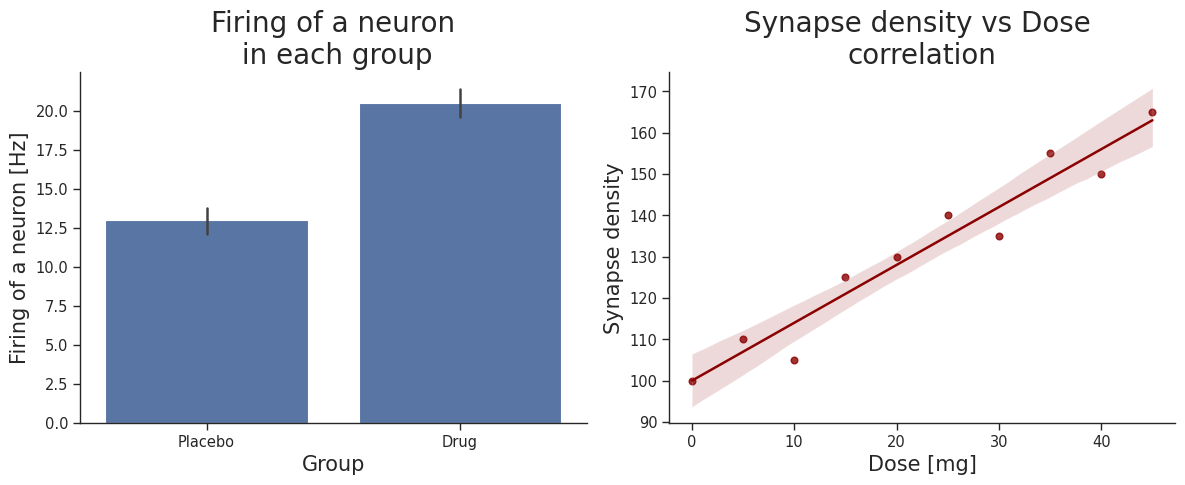

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# MEMORIZE
# slope = the "m" in y = mx + b
# intercept = the "b" in y = mx + b
# r_val = the correlation coefficient
# p_val = the probability of random luck
# std_err = the error of the slope



#Clean visuals
sns.set_theme(style="ticks", context="paper", font_scale=1.2)

# Data for graph and error bars
group_data = {
    'Group': ['Placebo']*10 + ['Drug']*10,
    'Neuron_Firing_Hz': [12, 14, 11, 13, 15, 12, 14, 13, 11, 15,
                         18, 22, 19, 21, 20, 23, 19, 22, 21, 20]
}
df_group = pd.DataFrame(group_data)

# Data for linear regression
reg_data = {
    'Dose_mg': [0, 5, 10, 15, 20, 25, 30, 35, 40, 45],
    'Synapse_Density': [100, 110, 105, 125, 130, 140, 135, 155, 150, 165]
}
df_reg = pd.DataFrame(reg_data)


drug_firing = df_group[df_group['Group'] == 'Drug']
sample_size = len(drug_firing)
mean_firing = drug_firing['Neuron_Firing_Hz'].mean()
STD = np.std(drug_firing['Neuron_Firing_Hz'])
SEM = STD / np.sqrt(sample_size)
print(f"standard deviation: {STD}")
print(f"mean:  {mean_firing}")
print(f"SEM: {SEM}")
print("CI-95:", SEM*1.96)

slope, intercept, r_val, p_val, std_err = stats.linregress(df_reg['Dose_mg'], df_reg['Synapse_Density'])
r_squared = r_val ** 2

print(f"slope: {slope}")
print(f"intercept: {intercept}")
print(f"R-squared: {r_squared}")
print(f"P-value: {p_val}")
print(f"Standard error: {std_err}")

fig, ax = plt.subplots(1, 2, figsize=(12,5))
sns.barplot(data=df_group, x='Group', y='Neuron_Firing_Hz', ax=ax[0])
ax[0].set_title("Firing of a neuron\n in each group", fontsize=20)
ax[0].set_xlabel("Group", fontsize=15)
ax[0].set_ylabel("Firing of a neuron [Hz]", fontsize=15)

sns.regplot(data=df_reg, x='Dose_mg', y='Synapse_Density', color="darkred", ax=ax[1])
ax[1].set_title("Synapse density vs Dose \ncorrelation", fontsize=20)
ax[1].set_xlabel("Dose [mg]", fontsize=15)
ax[1].set_ylabel("Synapse density", fontsize=15)

sns.despine()
plt.tight_layout()
